In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
fear_greed = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")


/tmp/ipython-input-1774725867.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


In [3]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
fear_greed["date"] = pd.to_datetime(fear_greed["date"])


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97885 entries, 0 to 97884
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           97885 non-null  object 
 1   Coin              97884 non-null  object 
 2   Execution Price   97884 non-null  float64
 3   Size Tokens       97884 non-null  float64
 4   Size USD          97884 non-null  float64
 5   Side              97884 non-null  object 
 6   Timestamp IST     97884 non-null  object 
 7   Start Position    97884 non-null  float64
 8   Direction         97884 non-null  object 
 9   Closed PnL        97884 non-null  float64
 10  Transaction Hash  97884 non-null  object 
 11  Order ID          97884 non-null  float64
 12  Crossed           97884 non-null  object 
 13  Fee               97884 non-null  float64
 14  Trade ID          97884 non-null  float64
 15  Timestamp         97884 non-null  float64
dtypes: float64(9), object(7)
memory usage: 1

In [8]:
trades["time"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

After getting time column we drop 'Timestamp IST

In [9]:
trades.drop(columns=['Timestamp IST'],inplace=True)

In [10]:
trades["Date"] = trades["time"].dt.date
trades["Date"] = pd.to_datetime(trades["Date"])

In [11]:
trades[['time','Date']].head(3)

,time,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02


In [12]:
trades.head(4)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02


In [13]:
trades[['Side','Start Position','Direction']].sample(6)

,Side,Start Position,Direction
9989,BUY,39.69987,Open Long
7839,SELL,10.22172,Close Long
45478,SELL,78122.78000,Sell
2318,SELL,32403.54975,Sell
85184,SELL,387.18000,Close Long
64302,SELL,117565.74000,Close Long


Now we drop unnecessary columns

In [14]:
trades.drop(columns=['Account','Start Position','Direction','Transaction Hash','Order ID','Trade ID','Timestamp'],inplace=True)

In [15]:
trades.head(6)

,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Crossed,Fee,time,Date
0,@107,7.9769,986.87,7872.16,BUY,0.0,True,0.345404,2024-12-02 22:50:00,2024-12-02
1,@107,7.9800,16.00,127.68,BUY,0.0,True,0.005600,2024-12-02 22:50:00,2024-12-02
2,@107,7.9855,144.09,1150.63,BUY,0.0,True,0.050431,2024-12-02 22:50:00,2024-12-02
3,@107,7.9874,142.98,1142.04,BUY,0.0,True,0.050043,2024-12-02 22:50:00,2024-12-02
4,@107,7.9894,8.73,69.75,BUY,0.0,True,0.003055,2024-12-02 22:50:00,2024-12-02
5,@107,7.9900,1.41,11.27,BUY,0.0,True,0.000493,2024-12-02 22:50:00,2024-12-02


In [16]:
fear_greed.head(6)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
5,1517895000,8,Extreme Fear,2018-02-06


Checking where the dates match for merging

In [17]:
print("Trades date range:")
print(trades["Date"].min(), "to", trades["Date"].max())

print("\nFear-Greed date range:")
print(fear_greed["date"].min(), "to", fear_greed["date"].max())


Trades date range:
2023-05-01 00:00:00 to 2025-05-01 00:00:00

Fear-Greed date range:
2018-02-01 00:00:00 to 2025-05-02 00:00:00


Merge by every day trade

In [18]:
trades_merged = trades.merge(
    fear_greed[["date", "classification", "value"]],
    left_on="Date",
    right_on="date",
    how="left"
)

In [19]:
trades_merged.head(10)

,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Crossed,Fee,time,Date,date,classification,value
0,@107,7.9769,986.87,7872.16,BUY,0.0,True,0.345404,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
1,@107,7.9800,16.00,127.68,BUY,0.0,True,0.005600,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
2,@107,7.9855,144.09,1150.63,BUY,0.0,True,0.050431,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
3,@107,7.9874,142.98,1142.04,BUY,0.0,True,0.050043,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
4,@107,7.9894,8.73,69.75,BUY,0.0,True,0.003055,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
5,@107,7.9900,1.41,11.27,BUY,0.0,True,0.000493,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
6,@107,7.9934,144.09,1151.77,BUY,0.0,True,0.050431,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
7,@107,8.0000,34.00,272.00,BUY,0.0,True,0.011900,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
8,@107,8.0000,46.00,368.00,BUY,0.0,True,0.016100,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0
9,@107,8.0000,12.50,100.00,BUY,0.0,True,0.004375,2024-12-02 22:50:00,2024-12-02,2024-12-02,Extreme Greed,80.0


In [20]:
print(trades_merged["date"].min(), "to", trades_merged["date"].max())

2023-05-01 00:00:00 to 2025-05-01 00:00:00


In [21]:
trades_merged[trades_merged["classification"].isna()]

,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Crossed,Fee,time,Date,date,classification,value
727,EIGEN,2.8330,10000.00,28330.00,BUY,11655.000000,False,2.719680,2024-10-26 04:44:00,2024-10-26,NaT,NaN,NaN
728,EIGEN,2.7110,10797.51,29272.05,BUY,13901.794130,False,2.810115,2024-10-26 04:52:00,2024-10-26,NaT,NaN,NaN
729,EIGEN,2.5889,6908.33,17884.98,BUY,9737.981968,False,1.716957,2024-10-26 04:52:00,2024-10-26,NaT,NaN,NaN
730,EIGEN,2.5889,529.39,1370.54,BUY,746.228144,False,0.131570,2024-10-26 04:52:00,2024-10-26,NaT,NaN,NaN
731,EIGEN,2.5889,38.65,100.06,BUY,54.481040,False,0.009605,2024-10-26 04:52:00,2024-10-26,NaT,NaN,NaN
732,EIGEN,2.5889,4523.63,11711.23,BUY,6376.508848,False,1.124277,2024-10-26 04:53:00,2024-10-26,NaT,NaN,NaN
97884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN


In [22]:
trades_merged["Net PnL"] = trades_merged["Closed PnL"] - trades_merged["Fee"]

In [23]:
trades_merged = trades_merged.dropna()

In [24]:
trades_merged.shape

(97878, 14)

Grouping trades by dates and applying agregation functions

In [25]:
daily_trades = (
    trades
    .groupby("Date")
    .agg({
        "Closed PnL": "sum",
        "Fee": "sum",
        "Size USD": "sum",
        "Crossed": "mean"
    })
    .reset_index()
)

daily_trades["Net PnL"] = daily_trades["Closed PnL"] - daily_trades["Fee"]


In [26]:
daily_merged = daily_trades.merge(
    fear_greed[["date", "classification", "value"]],
    left_on="Date",
    right_on="date",
    how="left"
)


In [27]:
daily_merged[daily_merged['classification'].isna()]

,Date,Closed PnL,Fee,Size USD,Crossed,Net PnL,date,classification,value
280,2024-10-26,42471.99413,8.512204,88668.86,0.0,42463.481926,NaT,NaN,NaN


In [28]:
daily_merged = daily_merged.dropna(subset=['classification'])

In [29]:
daily_merged = daily_merged.sort_values("Date")
daily_merged[["classification", "value"]] = (
    daily_merged[["classification", "value"]].ffill()
)


In [30]:
daily_merged.drop(columns=['date'],inplace=True)

“The Fear–Greed index did not provide a value for 26-Oct-2024. Since it represented a single missing day, I excluded it to preserve data integrity without introducing assumptions.”

In [31]:
fear_greed[
    (fear_greed["date"] >= "2024-10-24") &
    (fear_greed["date"] <= "2024-10-28")
]


,timestamp,value,classification,date
2454,1729747800,69,Greed,2024-10-24
2455,1729834200,72,Greed,2024-10-25
2456,1730007000,74,Greed,2024-10-27
2457,1730093400,72,Greed,2024-10-28


In [32]:
daily_merged["classification"].isna().sum()


np.int64(0)

# Data preprocessing completed

---



In [33]:
trades_merged.to_csv('Each_trade.csv')

In [34]:
daily_merged.to_csv("Processed_data.csv")

In [35]:
daily_merged

,Date,Closed PnL,Fee,Size USD,Crossed,Net PnL,classification,value
0,2023-05-01,0.000000,0.000000,477.00,1.0,0.000000,Greed,63.0
1,2023-12-05,0.000000,12.501455,50005.83,1.0,-12.501455,Extreme Greed,75.0
2,2023-12-14,-205.434737,28.300831,113203.35,1.0,-233.735568,Greed,72.0
3,2023-12-15,-24.632034,2.652489,10609.95,1.0,-27.284523,Greed,70.0
4,2023-12-16,0.000000,3.837189,15348.77,1.0,-3.837189,Greed,67.0
...,...,...,...,...,...,...,...,...
462,2025-04-27,504.774376,13.609208,230062.85,0.147239,491.165168,Greed,61.0
463,2025-04-28,38702.572171,5774.993093,25130437.07,0.969871,32927.579078,Neutral,54.0
464,2025-04-29,117761.291571,4774.293849,32038427.95,0.698185,112986.997722,Greed,60.0
465,2025-04-30,10470.606956,2805.914434,11826798.95,0.996672,7664.692522,Greed,56.0


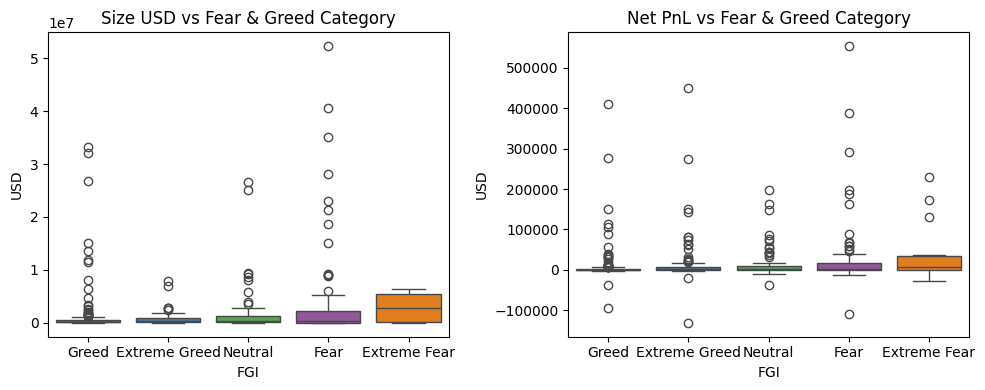

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Size USD vs Sentiment
sns.boxplot(
    x="classification",
    y="Size USD",
    hue="classification",
    data=daily_merged,
    palette="Set1",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Size USD vs Fear & Greed Category")
axes[0].set_ylabel("USD")
axes[0].set_xlabel("FGI")

# Net PnL vs Sentiment
sns.boxplot(
    x="classification",
    y="Net PnL",
    hue="classification",
    data=daily_merged,
    palette="Set1",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Net PnL vs Fear & Greed Category")
axes[1].set_ylabel("USD")
axes[1].set_xlabel("FGI")

plt.tight_layout()
plt.show()


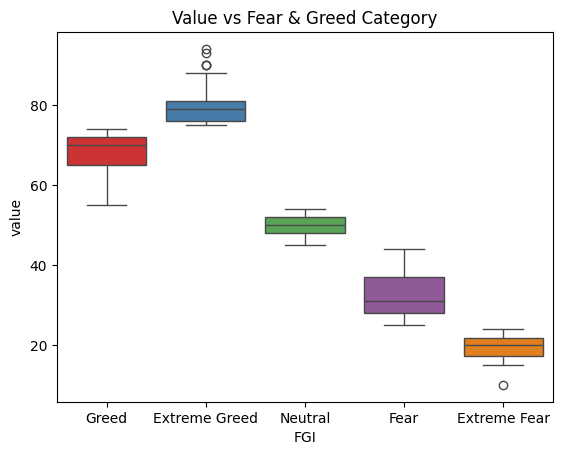

In [37]:
sns.boxplot(
    x="classification",
    y="value",
    hue="classification",
    data=daily_merged,
    palette="Set1",
    legend=False
)

plt.title("Value vs Fear & Greed Category")
plt.ylabel("value")
plt.xlabel("FGI")
plt.show()

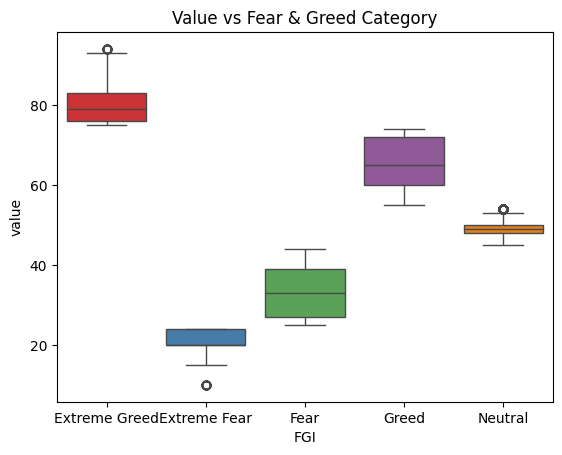

In [38]:
sns.boxplot(
    x="classification",
    y="value",
    hue="classification",
    data=trades_merged,
    palette="Set1",
    legend=False
)

plt.title("Value vs Fear & Greed Category")
plt.ylabel("value")
plt.xlabel("FGI")
plt.show()

In [41]:
trades_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97878 entries, 0 to 97883
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Coin             97878 non-null  object        
 1   Execution Price  97878 non-null  float64       
 2   Size Tokens      97878 non-null  float64       
 3   Size USD         97878 non-null  float64       
 4   Side             97878 non-null  object        
 5   Closed PnL       97878 non-null  float64       
 6   Crossed          97878 non-null  object        
 7   Fee              97878 non-null  float64       
 8   time             97878 non-null  datetime64[ns]
 9   Date             97878 non-null  datetime64[ns]
 10  date             97878 non-null  datetime64[ns]
 11  classification   97878 non-null  object        
 12  value            97878 non-null  float64       
 13  Net PnL          97878 non-null  float64       
dtypes: datetime64[ns](3), float64(7), object(4)

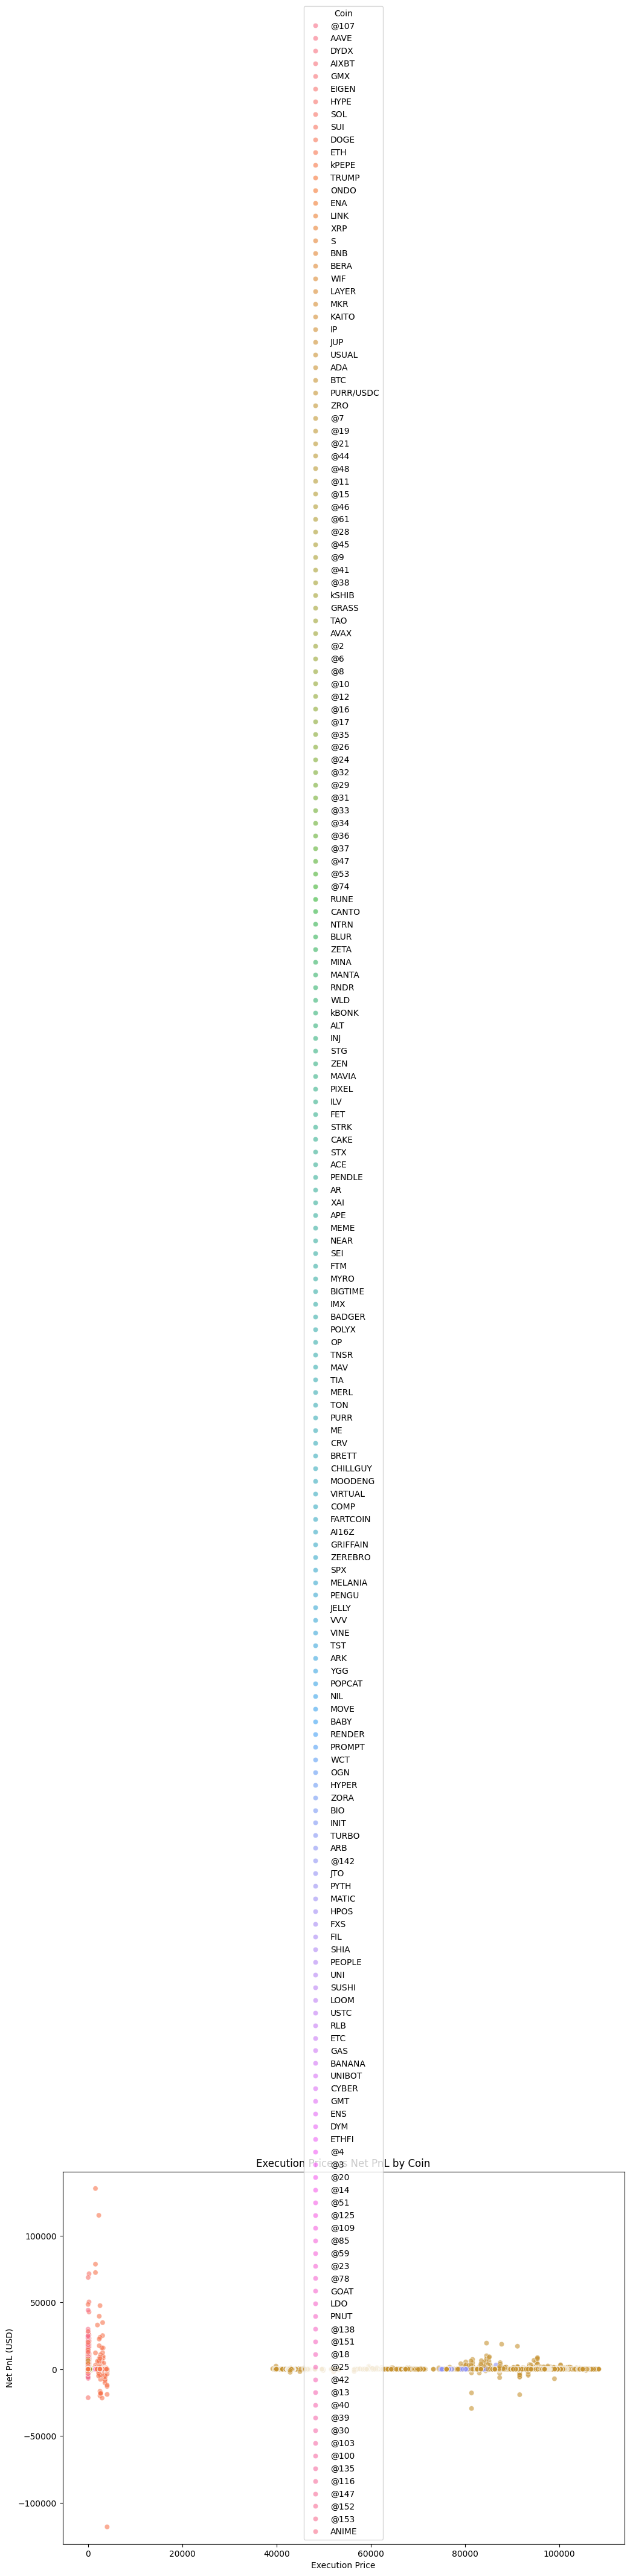

In [43]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=trades_merged,
    x="Execution Price",
    y="Net PnL",
    hue="Coin",
    alpha=0.6
)

plt.title("Execution Price vs Net PnL by Coin")
plt.xlabel("Execution Price")
plt.ylabel("Net PnL (USD)")
plt.show()


There are too many coins. lets plot only for to n coins

In [47]:
top_coins = (
    trades_merged.groupby("Coin")["Size USD"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)


In [48]:
filtered = trades_merged[trades_merged["Coin"].isin(top_coins)]

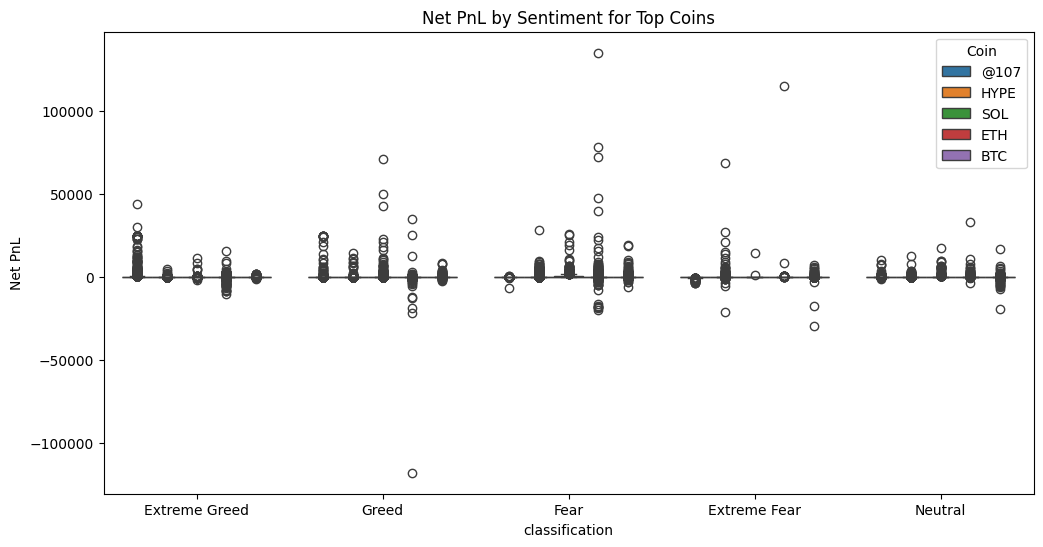

In [49]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=filtered,
    x="classification",
    y="Net PnL",
    hue="Coin"
)
plt.title("Net PnL by Sentiment for Top Coins")
plt.show()

In [50]:
trades_merged.sample(3)

,Coin,Execution Price,Size Tokens,Size USD,Side,Closed PnL,Crossed,Fee,time,Date,date,classification,value,Net PnL
77227,HYPE,13.412,14.91,199.97,SELL,5.136495,True,0.059991,2025-03-12 15:09:00,2025-03-12,2025-03-12,Fear,34.0,5.076504
54807,@107,22.095,19.73,435.93,BUY,0.000000,True,0.006905,2025-01-29 03:03:00,2025-01-29,2025-01-29,Greed,72.0,-0.006905
76098,HYPE,14.221,41.46,589.60,SELL,38.885334,True,0.147400,2025-03-12 01:40:00,2025-03-12,2025-03-12,Fear,34.0,38.737934


Trying to find relations btw sentiment and fields through visualization

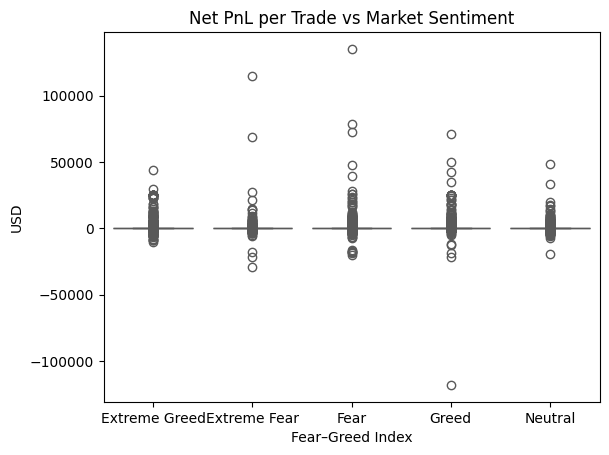

In [51]:
sns.boxplot(
    x="classification",
    y="Net PnL",
    hue="classification",
    data=trades_merged,
    palette="Set2",
    legend=False
)
plt.title("Net PnL per Trade vs Market Sentiment")
plt.ylabel("USD")
plt.xlabel("Fear–Greed Index")
plt.show()


In [52]:
trades_merged.groupby("classification")["Size USD"].median()

,Size USD
classification,
Extreme Fear,758.84
Extreme Greed,1012.53
Fear,793.25
Greed,1016.25
Neutral,565.53


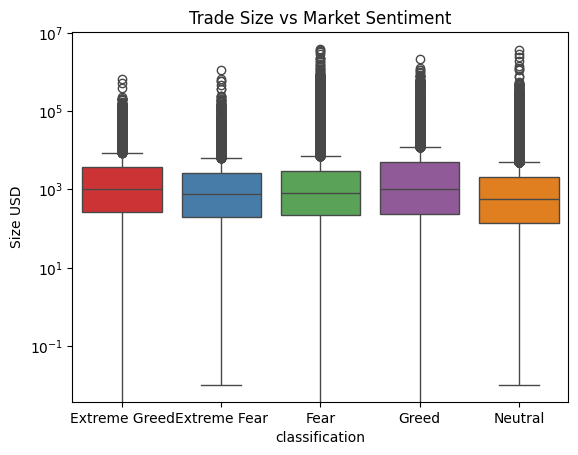

In [53]:
sns.boxplot(
    x="classification",
    y="Size USD",
    hue="classification",
    data=trades_merged,
    palette="Set1",
    legend=False
)
plt.yscale("log")
plt.title("Trade Size vs Market Sentiment")
plt.show()


In [54]:
trades_merged.groupby("classification")["Crossed"].mean() * 100


,Crossed
classification,
Extreme Fear,44.292237
Extreme Greed,43.613837
Fear,51.446583
Greed,61.380184
Neutral,51.337513


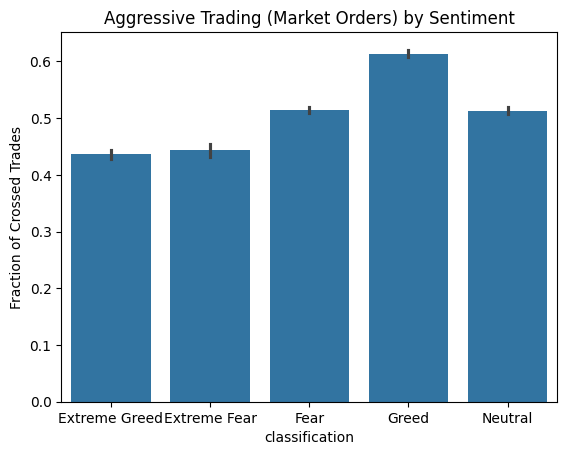

In [55]:
sns.barplot(
    x="classification",
    y="Crossed",
    data=trades_merged,
    estimator=np.mean
)
plt.title("Aggressive Trading (Market Orders) by Sentiment")
plt.ylabel("Fraction of Crossed Trades")
plt.show()


In [56]:
pd.crosstab(
    trades_merged["classification"],
    trades_merged["Side"],
    normalize="index"
) * 100


Side,BUY,SELL
classification,,
Extreme Fear,57.573386,42.426614
Extreme Greed,47.059233,52.940767
Fear,50.529906,49.470094
Greed,48.559671,51.440329
Neutral,54.538929,45.461071


In [57]:
trades_merged["win"] = trades_merged["Net PnL"] > 0

trades_merged.groupby("classification")["win"].mean() * 100


,win
classification,
Extreme Fear,36.738421
Extreme Greed,52.230807
Fear,43.808625
Greed,41.482386
Neutral,43.211944


In [58]:
trades_merged.groupby("classification")["Fee"].mean()


,Fee
classification,
Extreme Fear,0.888993
Extreme Greed,1.335208
Fear,1.748438
Greed,2.297474
Neutral,1.362444


In [59]:
trades_merged.groupby(["classification", "Crossed"])["Net PnL"].mean()


classification  Crossed
Extreme Fear    False       50.890016
                True       102.214805
Extreme Greed   False      107.430154
                True       136.124718
Fear            False       93.128580
                True        57.300899
Greed           False      100.478908
                True        49.583623
Neutral         False       24.827887
                True        81.292594
Name: Net PnL, dtype: float64

In [60]:
trades_merged["sentiment_num"] = trades_merged["classification"].map({
    "Extreme Fear":-2,
    "Fear": -1,
    "Neutral":0,
    "Greed": 1,
    "Extreme Greed":2
})


In [61]:
corr_cols = [
    "sentiment_num",
    "Size USD",
    "Net PnL",
    "Fee",
    "Crossed"
]

trades_merged[corr_cols].corr()


,sentiment_num,Size USD,Net PnL,Fee,Crossed
sentiment_num,1.000000,-0.006014,0.008515,0.013031,0.017409
Size USD,-0.006014,1.000000,0.132456,0.724965,0.055563
Net PnL,0.008515,0.132456,1.000000,0.107330,-0.002239
Fee,0.013031,0.724965,0.107330,1.000000,0.156345
Crossed,0.017409,0.055563,-0.002239,0.156345,1.000000


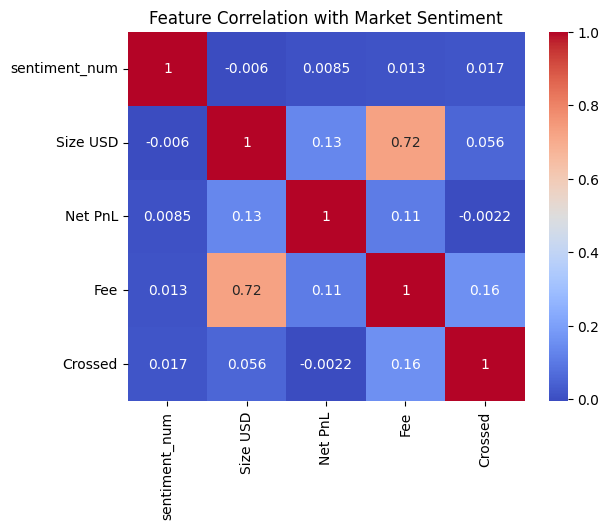

In [62]:
sns.heatmap(
    trades_merged[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation with Market Sentiment")
plt.show()


Risk-Adjusted Performance by Sentiment (VERY IMPORTANT)

In [70]:
risk_adj = trades_merged.groupby("classification")["Net PnL"].agg(
    mean="mean",
    std="std"
)

risk_adj["sharpe_like"] = risk_adj["mean"] / risk_adj["std"]
risk_adj

,mean,std,sharpe_like
classification,,,
Extreme Fear,73.622913,1719.745671,0.042810
Extreme Greed,119.944954,1200.942568,0.099876
Fear,74.696463,1199.572487,0.062269
Greed,69.239289,1319.794888,0.052462
Neutral,53.815463,626.702211,0.085871


Loss Severity vs Sentiment (Underrated)

In [64]:
losses = trades_merged[trades_merged["Net PnL"] < 0]

losses.groupby("classification")["Net PnL"].median()

,Net PnL
classification,
Extreme Fear,-0.254736
Extreme Greed,-0.147852
Fear,-0.128957
Greed,-0.253568
Neutral,-0.047108


In [66]:
#Execution Strategy × Sentiment (High Value)

pd.pivot_table(
    trades_merged,
    values="Net PnL",
    index="classification",
    columns="Crossed",
    aggfunc="mean"
)

Crossed,False,True
classification,,
Extreme Fear,50.890016,102.214805
Extreme Greed,107.430154,136.124718
Fear,93.128580,57.300899
Greed,100.478908,49.583623
Neutral,24.827887,81.292594


In [67]:
pd.pivot_table(
    trades_merged,
    values="win",
    index="classification",
    columns="Crossed",
    aggfunc="mean"
) * 100

Crossed,False,True
classification,,
Extreme Fear,23.606557,53.254786
Extreme Greed,57.437353,45.499521
Fear,39.829392,47.564080
Greed,53.665105,33.817137
Neutral,36.739109,49.347502


In [68]:
#Quantile Analysis (Professional Touch)
trades_merged.groupby("classification")["Net PnL"].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9]
)

classification      
Extreme Fear    0.10     -1.379667
                0.25     -0.088848
                0.50      0.000000
                0.75     11.302055
                0.90    107.289946
Extreme Greed   0.10     -2.189721
                0.25     -0.121440
                0.50      0.222318
                0.75     20.698531
                0.90    134.282337
Fear            0.10     -1.505344
                0.25     -0.145023
                0.50     -0.001008
                0.75      6.640379
                0.90     76.309147
Greed           0.10     -4.599888
                0.25     -0.520885
                0.50     -0.011524
                0.75      5.926967
                0.90     64.393882
Neutral         0.10     -1.049915
                0.25     -0.063988
                0.50     -0.003533
                0.75      5.144179
                0.90     59.081561
Name: Net PnL, dtype: float64